# THP Simples

Exemplo simples de treinamento do modelo **THP** (Transformer Hawkes Process).

## Objetivo

Treinar o modelo THP em dados sintéticos e verificar que ele converge corretamente.

In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

project_root = '/Users/hugoramossoares/Sites/EasyTemporalPointProcess'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from easy_tpp.model.torch_model.torch_thp import THP
from hawkes_data_utils import simulate_hawkes, prepare_batch

print("THP e utilitários importados com sucesso")

THP e utilitários importados com sucesso


In [2]:
# =============================================================================
# PARÂMETROS PARA GERAÇÃO DE DADOS SINTÉTICOS
# =============================================================================
HAWKES_MU = 0.3
HAWKES_ALPHA = 0.6
HAWKES_BETA = 1.3

NUM_TRAIN_SEQS = 2000
NUM_TEST_SEQS = 500
T_MAX = 100.0

# =============================================================================
# HIPERPARÂMETROS DO MODELO THP
# =============================================================================
HIDDEN_SIZE = 16
NUM_LAYERS = 1
NUM_HEADS = 2
DROPOUT = 0.2

# Hiperparâmetros de treinamento
LEARNING_RATE = 0.0005
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 100
BATCH_SIZE = 64

# Seed para reprodutibilidade
torch.manual_seed(42)

print("Configuração do THP:")
print(f"  hidden_size = {HIDDEN_SIZE}")
print(f"  num_layers = {NUM_LAYERS}")
print(f"  num_heads = {NUM_HEADS}")
print(f"  dropout = {DROPOUT}")

Configuração do THP:
  hidden_size = 16
  num_layers = 1
  num_heads = 2
  dropout = 0.2


In [3]:
print("Gerando dados de treino...")
train_raw = simulate_hawkes(HAWKES_MU, HAWKES_ALPHA, HAWKES_BETA, NUM_TRAIN_SEQS, T_MAX, seed=42)

print("Gerando dados de teste...")
test_raw = simulate_hawkes(HAWKES_MU, HAWKES_ALPHA, HAWKES_BETA, NUM_TEST_SEQS, T_MAX, seed=123)

# Preparar batches
batch_train = prepare_batch(train_raw)
batch_test = prepare_batch(test_raw)

print(f"\nDados sintéticos:")
print(f"Treino: {NUM_TRAIN_SEQS} sequências")
print(f"Teste:  {NUM_TEST_SEQS} sequências")
print(f"Shape: {batch_train[0].shape}")

Gerando dados de treino...
Gerando dados de teste...

Dados sintéticos:
Treino: 2000 sequências
Teste:  500 sequências
Shape: torch.Size([2000, 114])


In [4]:
class THPConfig:
    """Configuração simplificada para o modelo THP."""
    def __init__(self, hidden_size=32, num_layers=2, num_heads=4, dropout=0.1):
        # Parâmetros do modelo
        self.hidden_size = hidden_size
        self.time_emb_size = hidden_size
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout_rate = dropout
        self.use_ln = True
        
        # Parâmetros de evento (univariado)
        self.num_event_types = 1
        self.num_event_types_pad = 2
        self.pad_token_id = 1
        
        # Parâmetros de perda
        self.loss_integral_num_sample_per_step = 20
        self.use_mc_samples = False
        
        # Parâmetros de dispositivo
        self.gpu = -1
        
        # Thinning
        self.thinning = None

# Reset seed antes de criar modelo
torch.manual_seed(42)

config = THPConfig(
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    dropout=DROPOUT
)
model = THP(config)

# Contar parâmetros
num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calcular razão dados/parâmetros
total_events_train = sum(len(s) for s in train_raw)
ratio = total_events_train / num_params

print("Modelo THP criado!")
print(f"\nArquitetura:")
print(f"  Hidden size: {HIDDEN_SIZE}")
print(f"  Num layers: {NUM_LAYERS}")
print(f"  Num heads: {NUM_HEADS}")
print(f"  Total parâmetros: {num_params:,}")
print(f"  Parâmetros treináveis: {num_trainable:,}")
print(f"\nDados vs Modelo:")
print(f"  Eventos de treino: {total_events_train:,}")
print(f"  Razão eventos/parâmetros: {ratio:.2f}")

Modelo THP criado!

Arquitetura:
  Hidden size: 16
  Num layers: 1
  Num heads: 2
  Total parâmetros: 1,940
  Parâmetros treináveis: 1,940

Dados vs Modelo:
  Eventos de treino: 110,390
  Razão eventos/parâmetros: 56.90


In [ ]:
# Optimizer com weight decay para regularização
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=False
)

losses_train = []
losses_test = []
best_test_loss = float('inf')
best_epoch = 0

print(f"Iniciando treinamento com Batch Size = {BATCH_SIZE}...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    
    # Embaralhar dados de treino
    indices = np.random.permutation(len(train_raw))
    
    total_loss_train = 0
    total_events_train = 0
    
    # Mini-batch loop
    for i in range(0, len(train_raw), BATCH_SIZE):
        batch_idx = indices[i:i+BATCH_SIZE]
        batch_seqs = [train_raw[k] for k in batch_idx]
        batch_data = prepare_batch(batch_seqs)
        
        optimizer.zero_grad()
        loss, num_events = model.loglike_loss(batch_data)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss_train += loss.item()
        total_events_train += num_events
        
    # Média do NLL no treino
    nll_train = total_loss_train / total_events_train
    losses_train.append(nll_train)
    
    # Avaliação no teste
    model.eval()
    with torch.no_grad():
        loss_test, num_test = model.loglike_loss(batch_test)
        nll_test = loss_test / num_test
        losses_test.append(nll_test.item())
    
    # Atualizar scheduler
    scheduler.step(nll_test)
    
    # Track best model
    if nll_test.item() < best_test_loss:
        best_test_loss = nll_test.item()
        best_epoch = epoch
    
    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Train: {nll_train:.4f} | Test: {nll_test.item():.4f} | LR: {current_lr:.6f}")

print(f"\nTreinamento concluído!")
print(f"Melhor teste: {best_test_loss:.4f} (epoch {best_epoch})")


/Users/hugoramossoares/Sites/ebgeniusai/myenv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Iniciando treinamento com Batch Size = 64...

Epoch   1/100 | Train: 2.9495 | Test: 2.4258 | LR: 0.000500
Epoch  10/100 | Train: 0.9989 | Test: 0.5588 | LR: 0.000500
Epoch  20/100 | Train: 0.5100 | Test: 0.0919 | LR: 0.000500
Epoch  30/100 | Train: 0.2194 | Test: -0.1581 | LR: 0.000500
Epoch  40/100 | Train: 0.0534 | Test: -0.3251 | LR: 0.000500
Epoch  50/100 | Train: -0.0854 | Test: -0.4501 | LR: 0.000500
Epoch  60/100 | Train: -0.1356 | Test: -0.5414 | LR: 0.000500
Epoch  70/100 | Train: -0.1718 | Test: -0.6052 | LR: 0.000500
Epoch  80/100 | Train: -0.3054 | Test: -0.6795 | LR: 0.000500
Epoch  90/100 | Train: -0.5442 | Test: -1.0081 | LR: 0.000500
Epoch 100/100 | Train: -0.6437 | Test: -1.1121 | LR: 0.000500

Treinamento concluído!
Melhor teste: -1.1132 (epoch 99)


In [6]:
print("Resultado Final")
print("=" * 50)

best_test_epoch = np.argmin(losses_test) + 1

print(f"\nNLL Final (Treino): {losses_train[-1]:.4f}")
print(f"NLL Final (Teste):  {losses_test[-1]:.4f}")

print(f"\nMelhor NLL Teste: {min(losses_test):.4f} (epoch {best_test_epoch})")

# Verificar convergência
gap = losses_test[-1] - losses_train[-1]
print(f"\nGap (Teste - Treino): {gap:.4f}")

Resultado Final

NLL Final (Treino): -0.6437
NLL Final (Teste):  -1.1121

Melhor NLL Teste: -1.1132 (epoch 99)

Gap (Teste - Treino): -0.4684


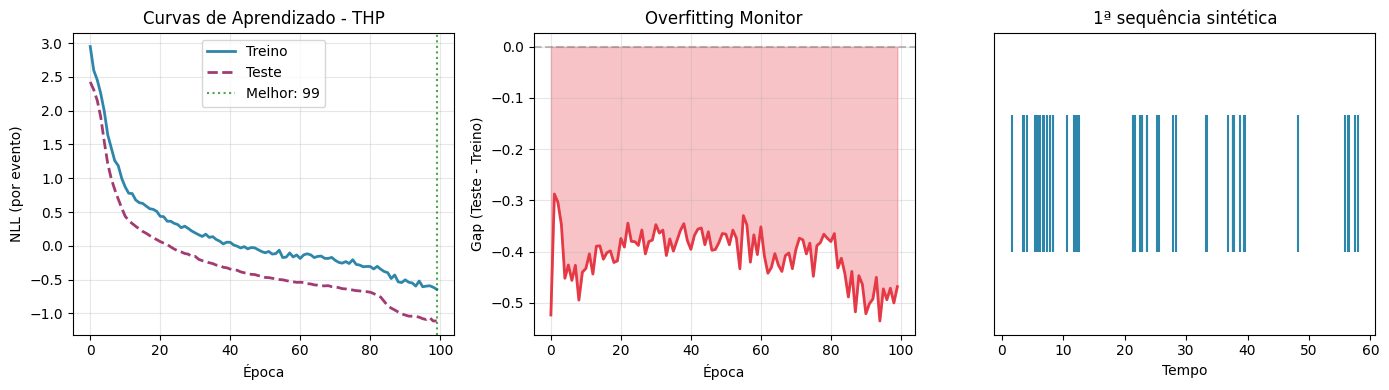

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Curvas de Aprendizado
axes[0].plot(losses_train, label='Treino', color='#2E86AB', linewidth=2)
axes[0].plot(losses_test, label='Teste', color='#A23B72', linewidth=2, linestyle='--')
axes[0].axvline(best_test_epoch, color='green', linestyle=':', alpha=0.7, label=f'Melhor: {best_test_epoch}')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('NLL (por evento)')
axes[0].set_title('Curvas de Aprendizado - THP')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Gap Treino-Teste (overfitting monitor)
gap = [t - tr for t, tr in zip(losses_test, losses_train)]
axes[1].plot(gap, color='#E63946', linewidth=2)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].fill_between(range(len(gap)), gap, alpha=0.3, color='#E63946')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Gap (Teste - Treino)')
axes[1].set_title('Overfitting Monitor')
axes[1].grid(True, alpha=0.3)

# 3. Exemplo de Sequência
example_seq = train_raw[0][:50]
axes[2].eventplot([example_seq], colors='#2E86AB', lineoffsets=0, linelengths=0.5)
axes[2].set_xlabel('Tempo')
axes[2].set_title('1ª sequência sintética')
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

## Notas

### Critérios de Convergência

- **NLL diminuindo**: Treino e teste devem diminuir ao longo das épocas
- **Gap controlado**: A diferença entre teste e treino não deve explodir
- **Estabilização**: O modelo deve estabilizar após certo número de épocas

### Sobre o THP

O THP (Transformer Hawkes Process) usa:
- Multi-head self-attention para capturar dependências temporais
- Positional encoding sinusoidal para codificar tempos
- Intensidade condicional baseada em hidden states do Transformer